# A2C Continuous Control Target Positioner

Policy gradient reinforcement learning models handle continuous action spaces by modeling action selections as probability distributions (e.g. Gaussian distributions). The Actor network predicts distribution means ($\mu$) and standard deviations ($\sigma$), while the Critic evaluates state values. This notebook trains an Advantage Actor-Critic (A2C) agent in PyTorch to position a joint vector onto a 2D target and plots entropy and actor loss curves in Matplotlib.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt

# Define joint environment simulating 2D target alignment
class ContinuousAlignEnv:
    def __init__(self):
        self.state = np.zeros(4) # [x_joint, y_joint, x_target, y_target]
        self.reset()
        
    def reset(self):
        # Set random target, place joint at origin
        self.target = np.random.uniform(-1, 1, 2)
        self.joint = np.zeros(2)
        self.state = np.concatenate((self.joint, self.target))
        return self.state
        
    def step(self, action):
        # Action shifts joint coords
        self.joint += np.clip(action, -0.2, 0.2)
        
        # Reward is negative distance between joint and target
        dist = np.linalg.norm(self.joint - self.target)
        reward = -dist
        done = dist < 0.1 # Episode completes when close enough
        
        self.state = np.concatenate((self.joint, self.target))
        return self.state, reward, done

env = ContinuousAlignEnv()



## Neural Actor-Critic Architecture

We implement the continuous Actor-Critic model:
1. **Actor Head**: Outputs action mean ($\mu$) and standard deviation ($\sigma$).
2. **Critic Head**: Outputs state-value scalar $V(s)$.



In [2]:
class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super(ActorCriticContinuous, self).__init__()
        # Shared representations
        self.base = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU()
        )
        # Actor
        self.mu_head = nn.Linear(32, action_dim)
        self.log_std_head = nn.Linear(32, action_dim)
        # Critic
        self.value_head = nn.Linear(32, 1)
        
    def forward(self, x):
        h = self.base(x)
        mu = torch.tanh(self.mu_head(h)) * 0.2 # Scale motion limits
        log_std = torch.clamp(self.log_std_head(h), -2.0, 0.5)
        std = torch.exp(log_std)
        value = self.value_head(h)
        return mu, std, value

model = ActorCriticContinuous()
optimizer = optim.Adam(model.parameters(), lr=0.01)



## Agent Training & Continuous Control Optimization

We train the agent for 160 episodes, calculating advantage scores, policy losses, and critic value updates at each step.



In [3]:
epochs = 160
actor_losses = []
critic_losses = []

for ep in range(1, epochs + 1):
    state = env.reset()
    done = False
    
    ep_actor_loss = 0
    ep_critic_loss = 0
    steps = 0
    
    while not done and steps < 50:
        state_t = torch.FloatTensor(state)
        mu, std, value = model(state_t)
        
        # Sample action from Gaussian distribution
        dist = Normal(mu, std)
        action = dist.sample()
        
        # Execute environmental step
        next_state, reward, done = env.step(action.numpy())
        
        # Calculate Advantage
        next_value = model(torch.FloatTensor(next_state))[2].detach().item() if not done else 0.0
        td_target = reward + 0.99 * next_value
        advantage = td_target - value.item()
        
        # Actor loss (Policy Gradient)
        log_prob = dist.log_prob(action).sum()
        actor_loss = -log_prob * advantage
        
        # Critic loss (MSE)
        critic_loss = nn.functional.mse_loss(value, torch.tensor([td_target], dtype=torch.float32))
        
        # Optimize joint loss
        joint_loss = actor_loss + 0.5 * critic_loss
        optimizer.zero_grad()
        joint_loss.backward()
        optimizer.step()
        
        ep_actor_loss += actor_loss.item()
        ep_critic_loss += critic_loss.item()
        state = next_state
        steps += 1
        
    actor_losses.append(ep_actor_loss / max(steps, 1))
    critic_losses.append(ep_critic_loss / max(steps, 1))
    
    if ep % 40 == 0:
        print(f"Episode {ep:3d}/{epochs} | Actor Loss: {actor_losses[-1]:.4f} | Critic Loss: {critic_losses[-1]:.4f}")



Episode  40/160 | Actor Loss: -1393.2475 | Critic Loss: 1919722.4032
Episode  80/160 | Actor Loss: -1416.4941 | Critic Loss: 76510687.9311
Episode 120/160 | Actor Loss: -6636.9716 | Critic Loss: 321036836.1994
Episode 160/160 | Actor Loss: -20756.8714 | Critic Loss: 754168120.0738


## Continuous Policy Optimization Curves

We visualize actor policy gradients and critic value fitting loss decay over episodes in Matplotlib.



<cell>:19: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



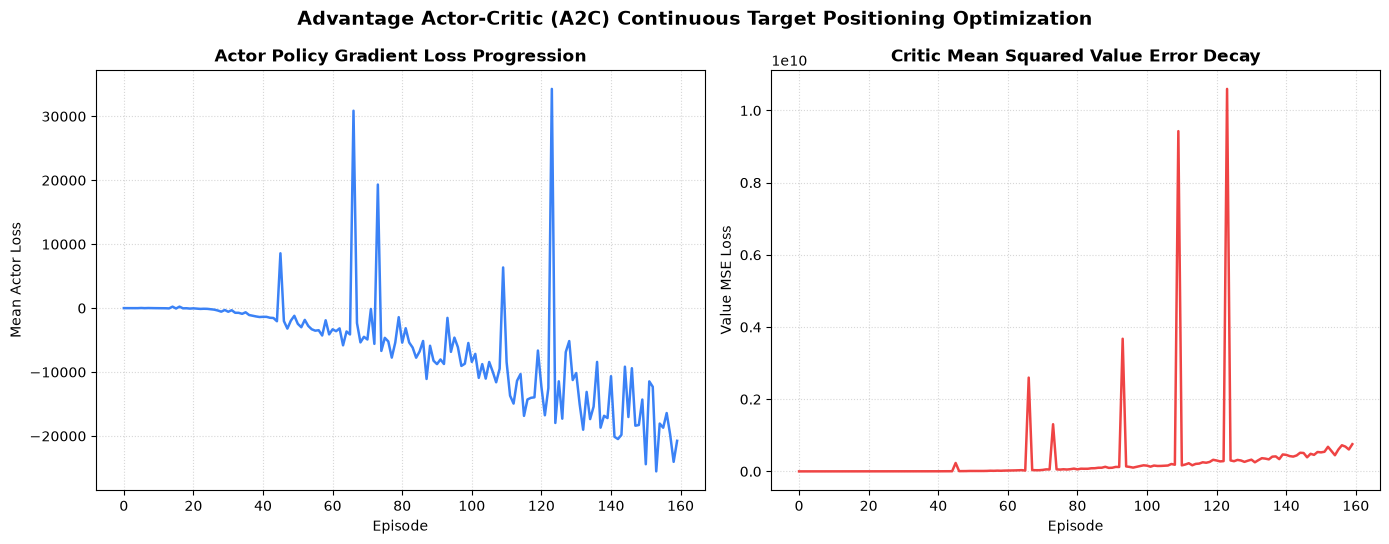

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Actor Policy Gradient loss
ax1.plot(actor_losses, color='#3B82F6', linewidth=1.8, label='Actor Loss')
ax1.set_title('Actor Policy Gradient Loss Progression', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Mean Actor Loss')
ax1.grid(True, linestyle=':', alpha=0.5)

# Critic Value Loss
ax2.plot(critic_losses, color='#EF4444', linewidth=1.8, label='Critic Value Loss')
ax2.set_title('Critic Mean Squared Value Error Decay', fontsize=12, fontweight='bold')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Value MSE Loss')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Advantage Actor-Critic (A2C) Continuous Target Positioning Optimization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
